# Visualizing Serpent Sensitivity Profiles

This example demonstrates how to use the `andalus` package to process and visualize sensitivity profiles generated by the **Serpent-2** Monte Carlo neutron transport code. Sensitivity analysis is crucial in nuclear data assimilation to understand how uncertainties in specific cross-sections affect integral parameters like $k_{\text{eff}}$.

### 1. Setup and Imports
First, we import `matplotlib` for figure customization and the `andalus` core package.

In [ ]:
import matplotlib.pyplot as plt

import andalus

plt.style.use("ggplot")

### 2. Reading Serpent Output
We use the `Sensitivity.from_serpent` method to parse the `.m` file. 

In this example, we examine the **HMF001** (Godiva) benchmark. We filter the perturbations (`pertlist`) for specific reaction types (MT) as denoted in the sens0.m output file:
* `mt 2`: Elastic scattering
* `mt 4`: Inelastic scattering
* `mt 18`: Fission
* `mt 102`: Radiative capture
* `nubar prompt`: Average number of outgoing prompt neutrons per fission
* `chi prompt`: Outgoing prompt neutron energy distribution

In [3]:
file_path = "../data/hmf001.ser_sens0.m"
hmf001 = andalus.Sensitivity.from_serpent(
    sens0_path=file_path, title="HMF001", pertlist=["mt 2 xs", "mt 4 xs", "mt 18 xs", "mt 102 xs"]
)

Reading ../data/hmf001.ser_sens0.m
  - done


### 3. Plotting Energy-Dependent Sensitivities
We can now plot the sensitivity profiles for specific isotopes. Below, we focus on U-235 (ZAI 922350) for Fission (MT 18) and Capture (MT 102) reactions.

C:\Users\dhouben\Documents\andalus\andalus\sensitivity.py:246: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = self.loc[zai, pert]


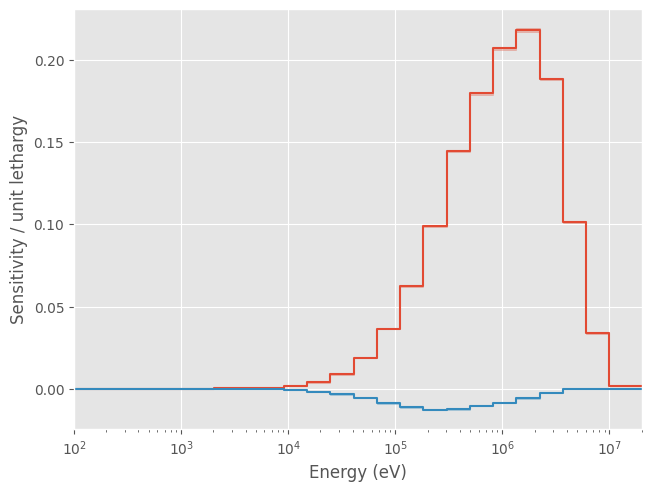

In [4]:
zais = [922350]  # U-235
perts = [18, 102]  # Fission and Capture

fig, ax = plt.subplots(layout="constrained")

for zai in zais:
    for pert in perts:
        hmf001.plot_sensitivity(zais=[zai], perts=[pert], ax=ax)

ax.set(
    xlim=(1e2, 2e7),
)

plt.show()

Next, we plot the sensitivity profiles for U-234. As $k_{\text{eff}}$ is less sensitive to U-234, the sensitivity estimates obtained via Serpent also suffers more from statistical noise. When plotting sensitivity profiles using ANDALUS, the 1 $\sigma$ uncertainty is included by default and is visualized as a shaded region around the nominal values.

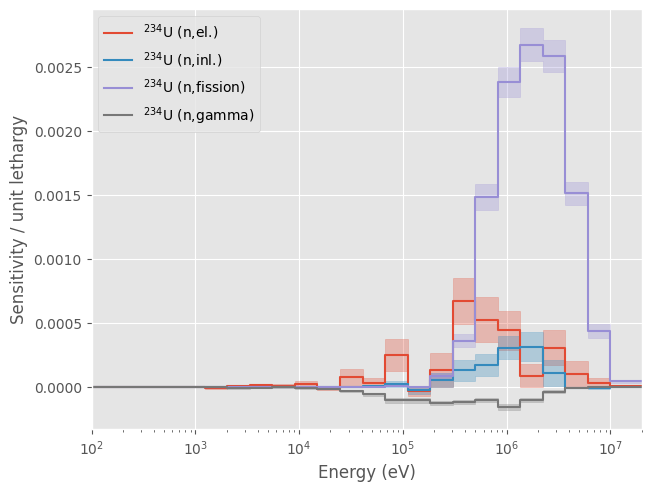

In [8]:
zais = [922340]  # U-234
perts = [2, 4, 18, 102]  # Fission and Capture

fig, ax = plt.subplots(layout="constrained")

for zai in zais:
    for pert in perts:
        hmf001.plot_sensitivity(zais=[zai], perts=[pert], ax=ax)

ax.set(
    xlim=(1e2, 2e7),
)

ax.legend()

plt.show()

### 4. Data Inspection
The `Sensitivity` object behaves like a MultiIndexed Pandas DataFrame, allowing for easy energy-bin inspection and statistical uncertainty analysis (`HMF001_std`).

In [9]:
# Displaying the top of the sensitivity matrix
hmf001.head(10)

HMF001  HMF001_std
ZAI    MT E_min_eV E_max_eV                     
922340 2  0.00001  0.10000       0.0         0.0
          0.10000  0.54000       0.0         0.0
          0.54000  4.00000       0.0         0.0
          4.00000  8.31529       0.0         0.0
          8.31529  13.70960      0.0         0.0
          13.70960 22.60330      0.0         0.0
          22.60330 40.16900      0.0         0.0
          40.16900 67.90400      0.0         0.0
          67.90400 91.66090      0.0         0.0
          91.66090 148.62500     0.0         0.0